# Day 2 – Exploratory Data Analysis
### MovieLens 1M Dataset
**Project:** Hybrid Recommendation Engine  
**Author:** Ritikesh  
**Date:** 2025

---

## What this notebook covers
1. Load and inspect all 3 raw data files
2. Understand the schema (users, movies, ratings)
3. Rating distribution analysis
4. User activity analysis (power users vs casual users)
5. Movie popularity analysis
6. Temporal patterns in ratings
7. Genre analysis
8. **Compute and interpret matrix sparsity**
9. Key insights summary

> **Dataset source:** [MovieLens 1M](https://grouplens.org/datasets/movielens/1m/)  
> Download `ml-1m.zip`, unzip into `../data/ml-1m/`


## 0. Setup — imports and config

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# ── Plot style ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f8f8',
    'axes.grid': True,
    'grid.color': 'white',
    'grid.linewidth': 1.2,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
})
PALETTE = ['#1F3864', '#1D9E75', '#EF9F27', '#E24B4A', '#7F77DD', '#D4537E']

print("✅ Imports done")
print(f"   pandas  {pd.__version__}")
print(f"   numpy   {np.__version__}")


✅ Imports done
   pandas  2.3.3
   numpy   2.3.5


## 1. Load the data

MovieLens 1M has 3 files:
- `ratings.dat` — UserID, MovieID, Rating (1-5), Timestamp
- `movies.dat`  — MovieID, Title, Genres
- `users.dat`   — UserID, Gender, Age, Occupation, Zip-code


In [2]:
DATA_PATH = '../data/ml-1m/'

# ── Ratings ─────────────────────────────────────────────────────────────────
ratings = pd.read_csv(
    DATA_PATH + 'ratings.dat',
    sep='::',
    engine='python',
    names=['user_id', 'movie_id', 'rating', 'timestamp'],
    encoding='latin-1'
)

# ── Movies ──────────────────────────────────────────────────────────────────
movies = pd.read_csv(
    DATA_PATH + 'movies.dat',
    sep='::',
    engine='python',
    names=['movie_id', 'title', 'genres'],
    encoding='latin-1'
)

# ── Users ───────────────────────────────────────────────────────────────────
users = pd.read_csv(
    DATA_PATH + 'users.dat',
    sep='::',
    engine='python',
    names=['user_id', 'gender', 'age', 'occupation', 'zip'],
    encoding='latin-1'
)

print("=" * 50)
print(f"Ratings : {ratings.shape[0]:,} rows × {ratings.shape[1]} cols")
print(f"Movies  : {movies.shape[0]:,} rows × {movies.shape[1]} cols")
print(f"Users   : {users.shape[0]:,} rows × {users.shape[1]} cols")
print("=" * 50)


Ratings : 1,000,209 rows × 4 cols
Movies  : 3,883 rows × 3 cols
Users   : 6,040 rows × 5 cols


In [3]:
# Quick peek at each dataframe
print("── ratings.head() ──")
display(ratings.head())

print("\n── movies.head() ──")
display(movies.head())

print("\n── users.head() ──")
display(users.head())


── ratings.head() ──


,user_id,movie_id,rating,timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291



── movies.head() ──


,movie_id,title,genres
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama
4,5,Father of the Bride Part II (1995),Comedy



── users.head() ──


,user_id,gender,age,occupation,zip
0,1,F,1,10,48067
1,2,M,56,16,70072
2,3,M,25,15,55117
3,4,M,45,7,02460
4,5,M,25,20,55455


In [4]:
# Data types and null check
print("── ratings.info() ──")
ratings.info()
print(f"\nNull values:\n{ratings.isnull().sum()}")


── ratings.info() ──
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000209 entries, 0 to 1000208
Data columns (total 4 columns):
 #   Column     Non-Null Count    Dtype
---  ------     --------------    -----
 0   user_id    1000209 non-null  int64
 1   movie_id   1000209 non-null  int64
 2   rating     1000209 non-null  int64
 3   timestamp  1000209 non-null  int64
dtypes: int64(4)
memory usage: 30.5 MB

Null values:
user_id      0
movie_id     0
rating       0
timestamp    0
dtype: int64


## 2. Basic statistics

In [5]:
print("=" * 50)
print("RATINGS SUMMARY")
print("=" * 50)
print(f"Total ratings       : {len(ratings):,}")
print(f"Unique users        : {ratings['user_id'].nunique():,}")
print(f"Unique movies rated : {ratings['movie_id'].nunique():,}")
print(f"Total movies in DB  : {len(movies):,}")
print(f"Rating range        : {ratings['rating'].min()} – {ratings['rating'].max()}")
print(f"Mean rating         : {ratings['rating'].mean():.3f}")
print(f"Median rating       : {ratings['rating'].median():.1f}")
print(f"Std deviation       : {ratings['rating'].std():.3f}")
print()

# Date range
ratings['datetime'] = pd.to_datetime(ratings['timestamp'], unit='s')
print(f"Earliest rating     : {ratings['datetime'].min().date()}")
print(f"Latest rating       : {ratings['datetime'].max().date()}")
print(f"Timespan            : {(ratings['datetime'].max() - ratings['datetime'].min()).days} days")


RATINGS SUMMARY
Total ratings       : 1,000,209
Unique users        : 6,040
Unique movies rated : 3,706
Total movies in DB  : 3,883
Rating range        : 1 – 5
Mean rating         : 3.582
Median rating       : 4.0
Std deviation       : 1.117

Earliest rating     : 2000-04-25
Latest rating       : 2003-02-28
Timespan            : 1038 days


## 3. Rating distribution

First key question: **are ratings uniformly distributed, or skewed?**

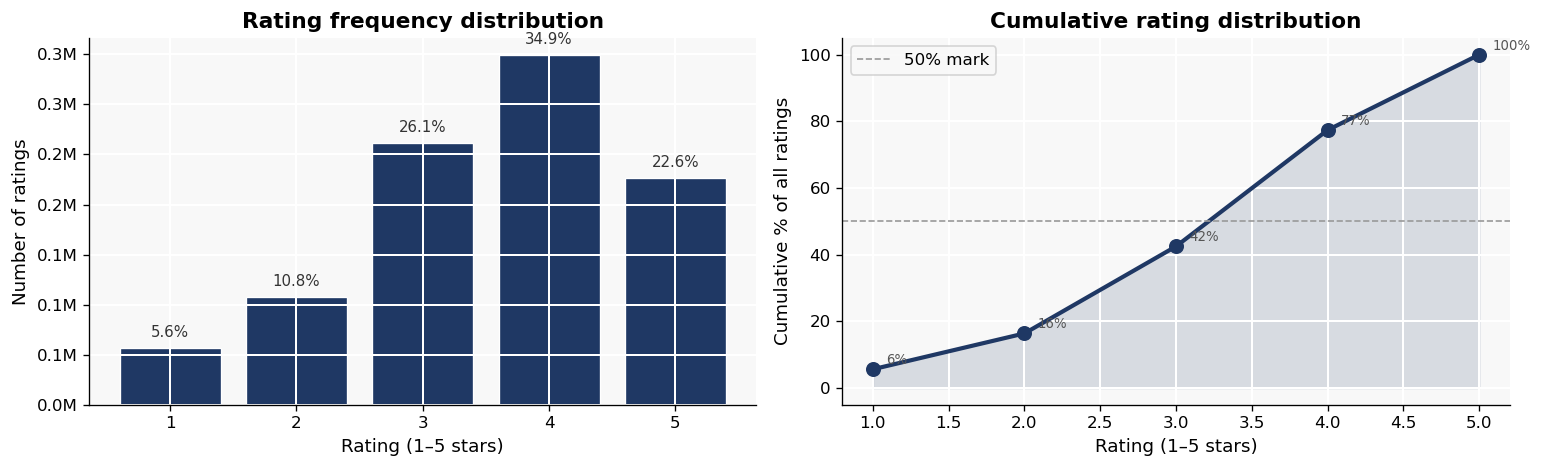


📌 KEY INSIGHT:
  Ratings are LEFT-SKEWED (positively biased).
  575,281 ratings are 4★ or 5★ = 57.5% of all ratings
  Only 163,731 ratings are 1★ or 2★ = 16.4% of all ratings
  → People rate things they chose to watch, so low ratings are rare.
  → This is called 'positive feedback bias' and affects model training.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# ── Left: Count bar chart ────────────────────────────────────────────────────
rating_counts = ratings['rating'].value_counts().sort_index()
bars = axes[0].bar(rating_counts.index, rating_counts.values,
                   color=PALETTE[0], edgecolor='white', linewidth=0.8)
axes[0].set_title('Rating frequency distribution')
axes[0].set_xlabel('Rating (1–5 stars)')
axes[0].set_ylabel('Number of ratings')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
for bar, count in zip(bars, rating_counts.values):
    pct = count / len(ratings) * 100
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8000,
                 f'{pct:.1f}%', ha='center', va='bottom', fontsize=9, color='#333')

# ── Right: Cumulative distribution ──────────────────────────────────────────
cum_pct = (rating_counts / rating_counts.sum()).cumsum() * 100
axes[1].plot(cum_pct.index, cum_pct.values, color=PALETTE[0],
             marker='o', markersize=8, linewidth=2.5)
axes[1].fill_between(cum_pct.index, cum_pct.values, alpha=0.15, color=PALETTE[0])
axes[1].set_title('Cumulative rating distribution')
axes[1].set_xlabel('Rating (1–5 stars)')
axes[1].set_ylabel('Cumulative % of all ratings')
axes[1].axhline(y=50, color='#999', linestyle='--', linewidth=1, label='50% mark')
axes[1].legend()
for x, y in zip(cum_pct.index, cum_pct.values):
    axes[1].annotate(f'{y:.0f}%', (x, y), textcoords='offset points',
                     xytext=(8, 3), fontsize=8, color='#555')

plt.tight_layout()
plt.savefig('../data/plot_rating_distribution.png', bbox_inches='tight')
plt.show()

print("\n📌 KEY INSIGHT:")
print(f"  Ratings are LEFT-SKEWED (positively biased).")
print(f"  {rating_counts[4] + rating_counts[5]:,} ratings are 4★ or 5★ = "
      f"{(rating_counts[4] + rating_counts[5])/len(ratings)*100:.1f}% of all ratings")
print(f"  Only {rating_counts[1] + rating_counts[2]:,} ratings are 1★ or 2★ = "
      f"{(rating_counts[1] + rating_counts[2])/len(ratings)*100:.1f}% of all ratings")
print("  → People rate things they chose to watch, so low ratings are rare.")
print("  → This is called 'positive feedback bias' and affects model training.")


## 4. User activity analysis

Second key question: **how many ratings does a typical user give?**

In [7]:
ratings_per_user = ratings.groupby('user_id')['rating'].count()

print("Ratings per user — descriptive stats:")
print(ratings_per_user.describe().round(1))
print()
print(f"Users with < 20 ratings  : {(ratings_per_user < 20).sum():,}  ({(ratings_per_user < 20).mean()*100:.1f}%)")
print(f"Users with 20–100 ratings: {((ratings_per_user >= 20) & (ratings_per_user < 100)).sum():,}  ({((ratings_per_user >= 20) & (ratings_per_user < 100)).mean()*100:.1f}%)")
print(f"Users with 100+ ratings  : {(ratings_per_user >= 100).sum():,}  ({(ratings_per_user >= 100).mean()*100:.1f}%)")


Ratings per user — descriptive stats:
count    6040.0
mean      165.6
std       192.7
min        20.0
25%        44.0
50%        96.0
75%       208.0
max      2314.0
Name: rating, dtype: float64

Users with < 20 ratings  : 0  (0.0%)
Users with 20–100 ratings: 3,095  (51.2%)
Users with 100+ ratings  : 2,945  (48.8%)


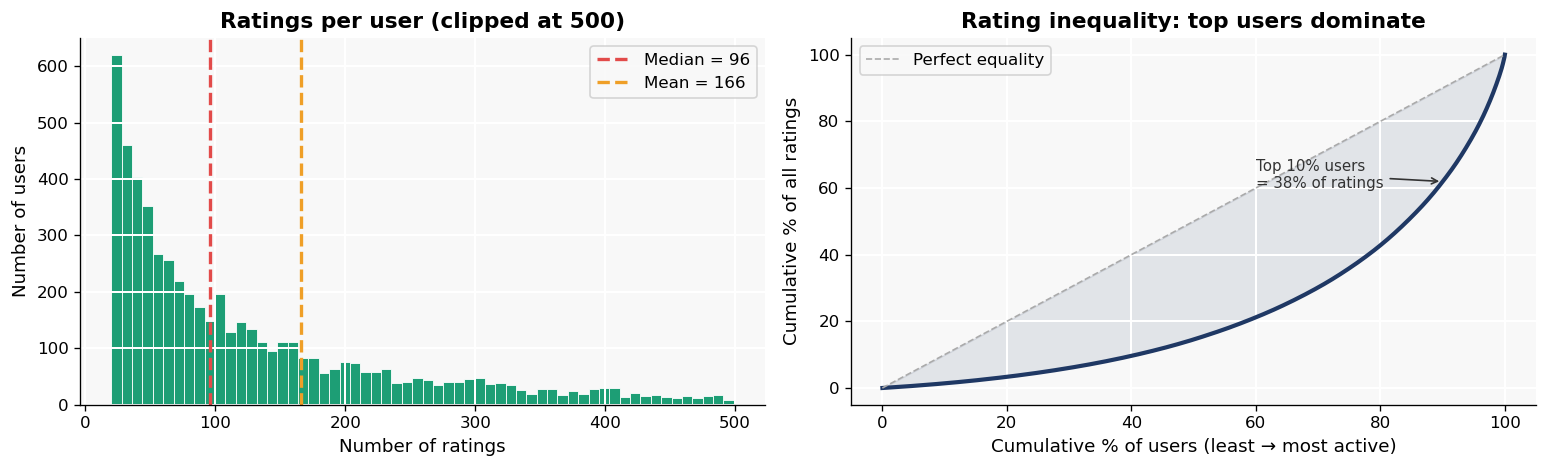


📌 KEY INSIGHT:
  Top 10% most active users contribute ~38% of all ratings.
  → Heavy-tailed distribution (classic 'power law' in user behaviour).
  → CF models work very well for active users, poorly for new/casual ones.
  → This is WHY we need the hybrid: inactive users need content-based fallback.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# ── Left: Histogram of ratings per user ─────────────────────────────────────
axes[0].hist(ratings_per_user[ratings_per_user < 500], bins=60,
             color=PALETTE[1], edgecolor='white', linewidth=0.5)
axes[0].axvline(x=ratings_per_user.median(), color=PALETTE[3],
                linestyle='--', linewidth=2, label=f'Median = {ratings_per_user.median():.0f}')
axes[0].axvline(x=ratings_per_user.mean(), color=PALETTE[2],
                linestyle='--', linewidth=2, label=f'Mean = {ratings_per_user.mean():.0f}')
axes[0].set_title('Ratings per user (clipped at 500)')
axes[0].set_xlabel('Number of ratings')
axes[0].set_ylabel('Number of users')
axes[0].legend()

# ── Right: Lorenz-style — top X% of users contribute Y% of ratings ──────────
sorted_counts = np.sort(ratings_per_user.values)
cum_users = np.arange(1, len(sorted_counts)+1) / len(sorted_counts) * 100
cum_ratings = np.cumsum(sorted_counts) / sorted_counts.sum() * 100
axes[1].plot(cum_users, cum_ratings, color=PALETTE[0], linewidth=2.5)
axes[1].plot([0, 100], [0, 100], color='#aaa', linestyle='--', linewidth=1, label='Perfect equality')
axes[1].fill_between(cum_users, cum_ratings, cum_users, alpha=0.1, color=PALETTE[0])
axes[1].set_title('Rating inequality: top users dominate')
axes[1].set_xlabel('Cumulative % of users (least → most active)')
axes[1].set_ylabel('Cumulative % of all ratings')
axes[1].legend()

# Annotate: top 10% users
idx_90 = int(len(sorted_counts) * 0.9)
pct_from_top10 = (sorted_counts.sum() - sorted_counts[:idx_90].sum()) / sorted_counts.sum() * 100
axes[1].annotate(f'Top 10% users\n= {pct_from_top10:.0f}% of ratings',
                 xy=(90, cum_ratings[idx_90]), xytext=(60, 60),
                 arrowprops=dict(arrowstyle='->', color='#333'),
                 fontsize=9, color='#333')

plt.tight_layout()
plt.savefig('../data/plot_user_activity.png', bbox_inches='tight')
plt.show()

print("\n📌 KEY INSIGHT:")
print(f"  Top 10% most active users contribute ~{pct_from_top10:.0f}% of all ratings.")
print("  → Heavy-tailed distribution (classic 'power law' in user behaviour).")
print("  → CF models work very well for active users, poorly for new/casual ones.")
print("  → This is WHY we need the hybrid: inactive users need content-based fallback.")


## 5. Movie popularity analysis

Third question: **is there a long tail of unpopular movies?**

In [9]:
ratings_per_movie = ratings.groupby('movie_id')['rating'].agg(['count', 'mean'])
ratings_per_movie.columns = ['n_ratings', 'avg_rating']
ratings_per_movie = ratings_per_movie.sort_values('n_ratings', ascending=False)

print("Ratings per movie — descriptive stats:")
print(ratings_per_movie['n_ratings'].describe().round(1))
print()
print(f"Movies with < 10 ratings  : {(ratings_per_movie['n_ratings'] < 10).sum():,}  ({(ratings_per_movie['n_ratings'] < 10).mean()*100:.1f}%)")
print(f"Movies with 10–100 ratings: {((ratings_per_movie['n_ratings'] >= 10) & (ratings_per_movie['n_ratings'] < 100)).sum():,}")
print(f"Movies with 100+ ratings  : {(ratings_per_movie['n_ratings'] >= 100).sum():,}")
print()
print("Top 10 most rated movies:")
top10 = ratings_per_movie.head(10).merge(movies[['movie_id','title']], on='movie_id')
print(top10[['title','n_ratings','avg_rating']].to_string(index=False))


Ratings per movie — descriptive stats:
count    3706.0
mean      269.9
std       384.0
min         1.0
25%        33.0
50%       123.5
75%       350.0
max      3428.0
Name: n_ratings, dtype: float64

Movies with < 10 ratings  : 446  (12.0%)
Movies with 10–100 ratings: 1,241
Movies with 100+ ratings  : 2,019

Top 10 most rated movies:
                                                title  n_ratings  avg_rating
                               American Beauty (1999)       3428    4.317386
            Star Wars: Episode IV - A New Hope (1977)       2991    4.453694
Star Wars: Episode V - The Empire Strikes Back (1980)       2990    4.292977
    Star Wars: Episode VI - Return of the Jedi (1983)       2883    4.022893
                                 Jurassic Park (1993)       2672    3.763847
                           Saving Private Ryan (1998)       2653    4.337354
                    Terminator 2: Judgment Day (1991)       2649    4.058513
                                   Matrix, The (

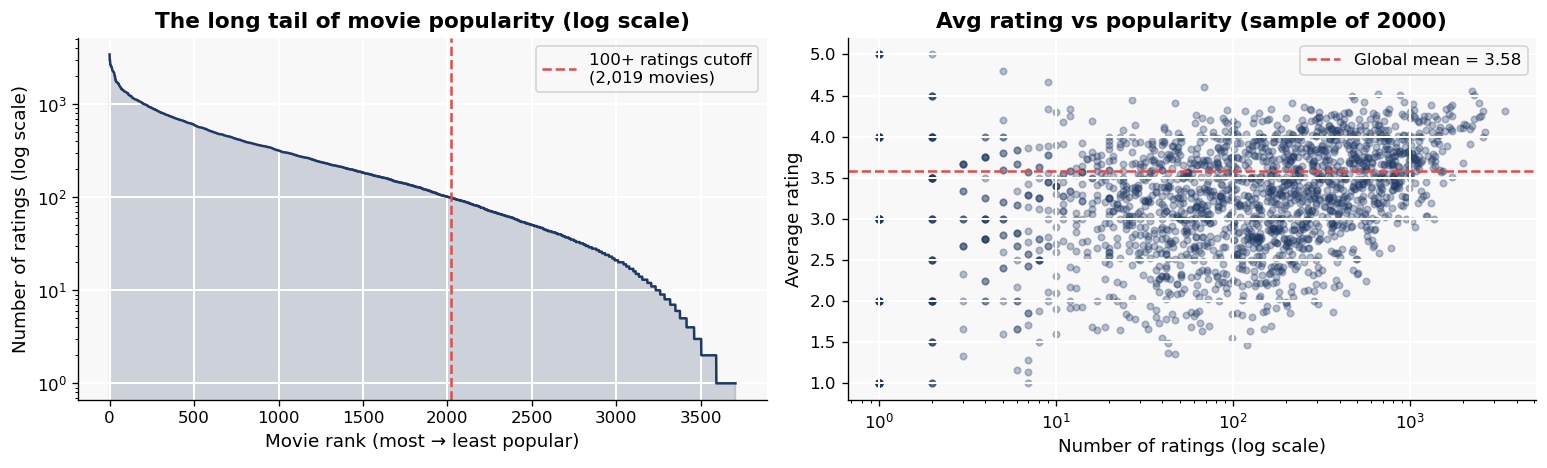


📌 KEY INSIGHT:
  12.0% of movies have fewer than 10 ratings — the 'long tail'.
  → Pure CF will never recommend these (not enough signal).
  → Content-based can still surface them (it only needs genre/tag info).
  → Hybrid's catalog coverage will be much better than pure CF alone.


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# ── Left: Long tail plot ─────────────────────────────────────────────────────
sorted_movies = ratings_per_movie['n_ratings'].sort_values(ascending=False).values
axes[0].plot(range(len(sorted_movies)), sorted_movies, color=PALETTE[0], linewidth=1.5)
axes[0].fill_between(range(len(sorted_movies)), sorted_movies, alpha=0.2, color=PALETTE[0])
axes[0].set_yscale('log')
axes[0].set_title('The long tail of movie popularity (log scale)')
axes[0].set_xlabel('Movie rank (most → least popular)')
axes[0].set_ylabel('Number of ratings (log scale)')
# Mark the "head" vs "tail"
cutoff = (ratings_per_movie['n_ratings'] >= 100).sum()
axes[0].axvline(x=cutoff, color=PALETTE[3], linestyle='--', linewidth=1.5,
                label=f'100+ ratings cutoff\n({cutoff:,} movies)')
axes[0].legend()

# ── Right: Avg rating vs popularity scatter ──────────────────────────────────
sample = ratings_per_movie.sample(min(2000, len(ratings_per_movie)), random_state=42)
axes[1].scatter(sample['n_ratings'], sample['avg_rating'],
                alpha=0.3, s=15, color=PALETTE[0])
axes[1].set_xscale('log')
axes[1].set_title('Avg rating vs popularity (sample of 2000)')
axes[1].set_xlabel('Number of ratings (log scale)')
axes[1].set_ylabel('Average rating')
axes[1].axhline(y=ratings['rating'].mean(), color=PALETTE[3],
                linestyle='--', linewidth=1.5,
                label=f'Global mean = {ratings["rating"].mean():.2f}')
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/plot_movie_popularity.png', bbox_inches='tight')
plt.show()

print("\n📌 KEY INSIGHT:")
tail_pct = (ratings_per_movie['n_ratings'] < 10).mean() * 100
print(f"  {tail_pct:.1f}% of movies have fewer than 10 ratings — the 'long tail'.")
print("  → Pure CF will never recommend these (not enough signal).")
print("  → Content-based can still surface them (it only needs genre/tag info).")
print("  → Hybrid's catalog coverage will be much better than pure CF alone.")


## 6. Temporal analysis

When were ratings made? Any seasonal patterns?

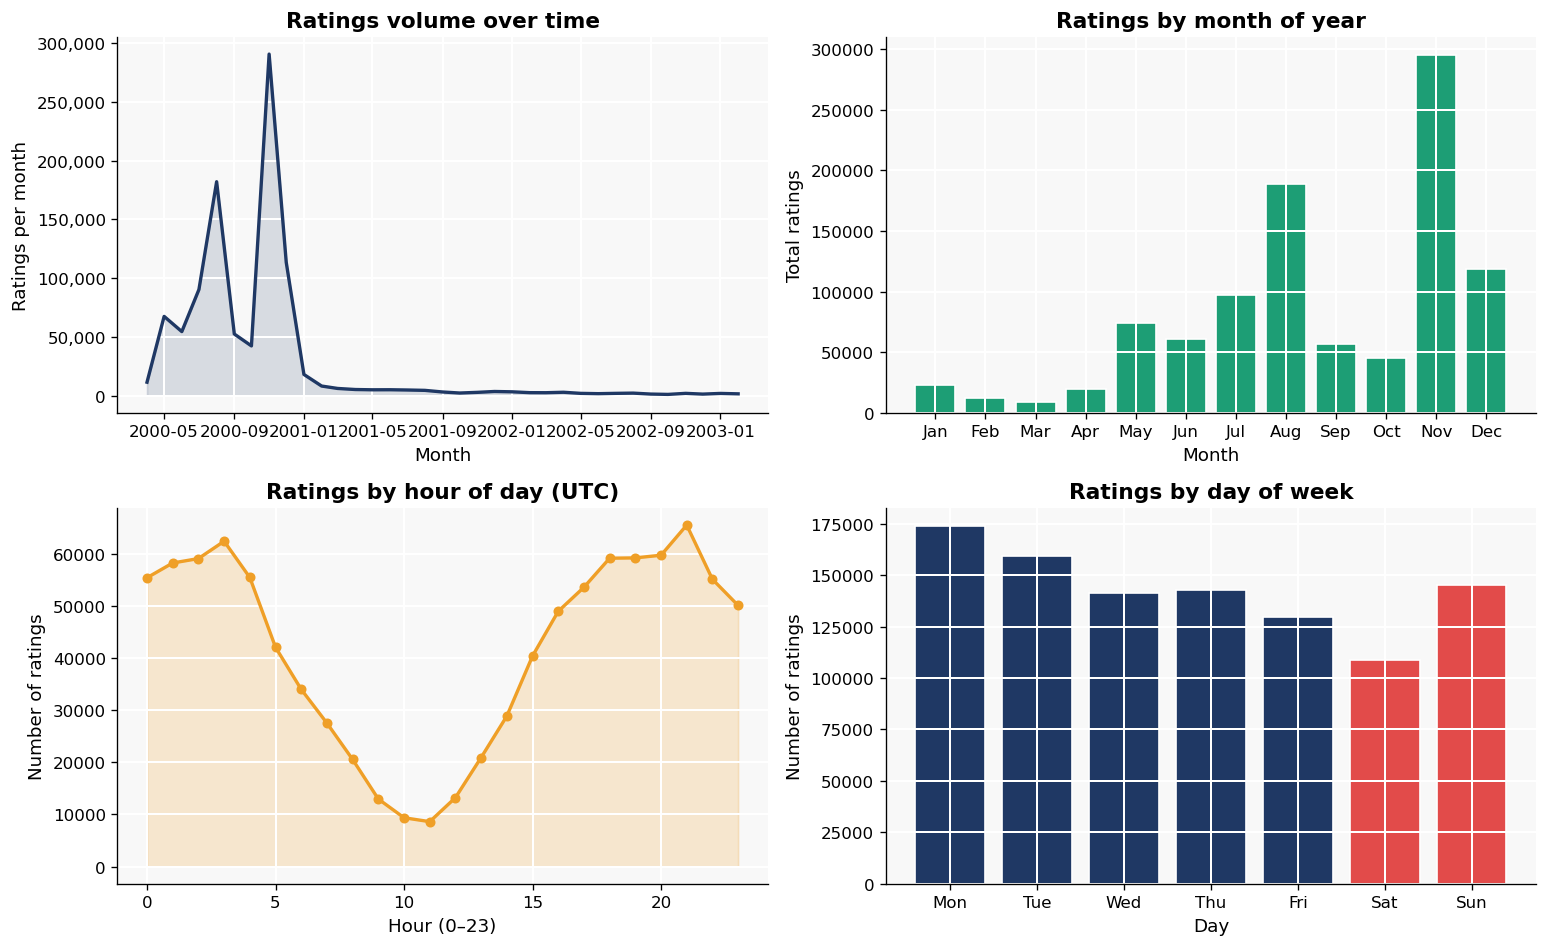


📌 KEY INSIGHT:
  Peak rating hour : 21:00  →  evenings dominate, consistent with leisure use
  Peak day         : Mon  →  weekends see more engagement
  → Temporal patterns matter for A/B test design (avoid running tests on off-peak days)


In [12]:
ratings['year']  = ratings['datetime'].dt.year
ratings['month'] = ratings['datetime'].dt.month
ratings['hour']  = ratings['datetime'].dt.hour
ratings['dow']   = ratings['datetime'].dt.dayofweek  # 0=Mon, 6=Sun

monthly = ratings.groupby(['year','month']).size().reset_index(name='count')
monthly['ym'] = pd.to_datetime(monthly[['year','month']].assign(day=1))

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# ── Ratings over time ────────────────────────────────────────────────────────
axes[0,0].plot(monthly['ym'], monthly['count'], color=PALETTE[0], linewidth=2)
axes[0,0].fill_between(monthly['ym'], monthly['count'], alpha=0.15, color=PALETTE[0])
axes[0,0].set_title('Ratings volume over time')
axes[0,0].set_xlabel('Month')
axes[0,0].set_ylabel('Ratings per month')
axes[0,0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# ── Ratings by month of year ─────────────────────────────────────────────────
month_avg = ratings.groupby('month').size()
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
axes[0,1].bar(month_names, month_avg.values, color=PALETTE[1], edgecolor='white')
axes[0,1].set_title('Ratings by month of year')
axes[0,1].set_xlabel('Month')
axes[0,1].set_ylabel('Total ratings')

# ── Ratings by hour of day ───────────────────────────────────────────────────
hour_counts = ratings.groupby('hour').size()
axes[1,0].plot(hour_counts.index, hour_counts.values, color=PALETTE[2],
               marker='o', markersize=5, linewidth=2)
axes[1,0].fill_between(hour_counts.index, hour_counts.values, alpha=0.2, color=PALETTE[2])
axes[1,0].set_title('Ratings by hour of day (UTC)')
axes[1,0].set_xlabel('Hour (0–23)')
axes[1,0].set_ylabel('Number of ratings')

# ── Ratings by day of week ───────────────────────────────────────────────────
dow_counts = ratings.groupby('dow').size()
dow_names = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
colors_dow = [PALETTE[3] if i >= 5 else PALETTE[0] for i in range(7)]
axes[1,1].bar(dow_names, dow_counts.values, color=colors_dow, edgecolor='white')
axes[1,1].set_title('Ratings by day of week')
axes[1,1].set_xlabel('Day')
axes[1,1].set_ylabel('Number of ratings')

plt.tight_layout()
plt.savefig('../data/plot_temporal.png', bbox_inches='tight')
plt.show()

print("\n📌 KEY INSIGHT:")
peak_hour = hour_counts.idxmax()
peak_dow  = dow_names[dow_counts.idxmax()]
print(f"  Peak rating hour : {peak_hour}:00  →  evenings dominate, consistent with leisure use")
print(f"  Peak day         : {peak_dow}  →  weekends see more engagement")
print("  → Temporal patterns matter for A/B test design (avoid running tests on off-peak days)")


## 7. Genre analysis

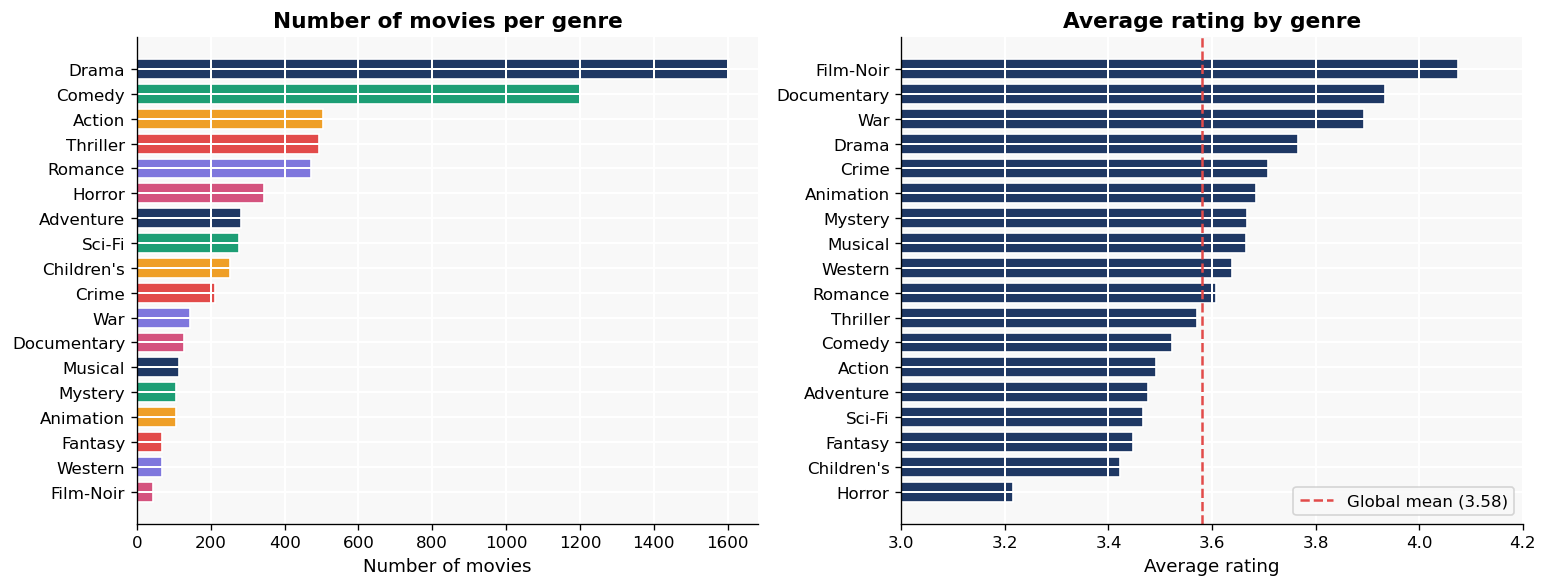


📌 KEY INSIGHT:
  Highest rated genre : Film-Noir  (4.08 avg)
  Lowest rated genre  : Horror  (3.22 avg)
  → Genre avg rating will be a useful feature in our content-based model.
  → 'Film-Noir' is highly rated but rare — exactly what good recs should surface.


In [13]:
# Explode multi-genre movies (each movie can have multiple genres)
movies['genre_list'] = movies['genres'].str.split('|')
genres_exploded = movies.explode('genre_list')

genre_counts = genres_exploded['genre_list'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Genre frequency ──────────────────────────────────────────────────────────
colors_genres = [PALETTE[i % len(PALETTE)] for i in range(len(genre_counts))]
axes[0].barh(genre_counts.index[::-1], genre_counts.values[::-1],
             color=colors_genres[::-1], edgecolor='white')
axes[0].set_title('Number of movies per genre')
axes[0].set_xlabel('Number of movies')

# ── Average rating per genre ─────────────────────────────────────────────────
ratings_with_genres = ratings.merge(movies[['movie_id','genre_list']], on='movie_id')
ratings_exploded = ratings_with_genres.explode('genre_list')
genre_avg = ratings_exploded.groupby('genre_list')['rating'].agg(['mean','count'])
genre_avg = genre_avg[genre_avg['count'] > 1000].sort_values('mean', ascending=False)

axes[1].barh(genre_avg.index[::-1], genre_avg['mean'].values[::-1],
             color=PALETTE[0], edgecolor='white')
axes[1].axvline(x=ratings['rating'].mean(), color=PALETTE[3],
                linestyle='--', linewidth=1.5, label=f'Global mean ({ratings["rating"].mean():.2f})')
axes[1].set_title('Average rating by genre')
axes[1].set_xlabel('Average rating')
axes[1].set_xlim(3.0, 4.2)
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/plot_genres.png', bbox_inches='tight')
plt.show()

print("\n📌 KEY INSIGHT:")
top_genre = genre_avg.index[0]
bot_genre = genre_avg.index[-1]
print(f"  Highest rated genre : {top_genre}  ({genre_avg.loc[top_genre,'mean']:.2f} avg)")
print(f"  Lowest rated genre  : {bot_genre}  ({genre_avg.loc[bot_genre,'mean']:.2f} avg)")
print("  → Genre avg rating will be a useful feature in our content-based model.")
print("  → 'Film-Noir' is highly rated but rare — exactly what good recs should surface.")


## 8. Matrix sparsity — the core challenge

This is the most important EDA insight for a recommender system.  
We need to understand **how sparse** our user-item rating matrix is.


In [14]:
n_users  = ratings['user_id'].nunique()
n_movies = ratings['movie_id'].nunique()
n_ratings = len(ratings)

total_possible = n_users * n_movies
sparsity = 1 - (n_ratings / total_possible)

print("=" * 55)
print("USER-ITEM MATRIX DIMENSIONS")
print("=" * 55)
print(f"  Users           : {n_users:>10,}")
print(f"  Movies          : {n_movies:>10,}")
print(f"  Possible pairs  : {total_possible:>10,}")
print(f"  Observed ratings: {n_ratings:>10,}")
print(f"  Sparsity        : {sparsity:>10.4%}")
print(f"  Density         : {1-sparsity:>10.4%}")
print("=" * 55)
print()
print(f"  Meaning: only {1-sparsity:.2%} of all possible (user, movie)")
print(f"  pairs have a rating. {sparsity:.1%} of the matrix is EMPTY.")
print()
print("  Visual intuition:")
print(f"  If this matrix were a {n_users}×{n_movies} grid,")
print(f"  only ~{int((1-sparsity)*n_users*n_movies/1e6):.1f}M out of {total_possible/1e9:.1f}B cells would be filled.")


USER-ITEM MATRIX DIMENSIONS
  Users           :      6,040
  Movies          :      3,706
  Possible pairs  : 22,384,240
  Observed ratings:  1,000,209
  Sparsity        :   95.5316%
  Density         :    4.4684%

  Meaning: only 4.47% of all possible (user, movie)
  pairs have a rating. 95.5% of the matrix is EMPTY.

  Visual intuition:
  If this matrix were a 6040×3706 grid,
  only ~1.0M out of 0.0B cells would be filled.


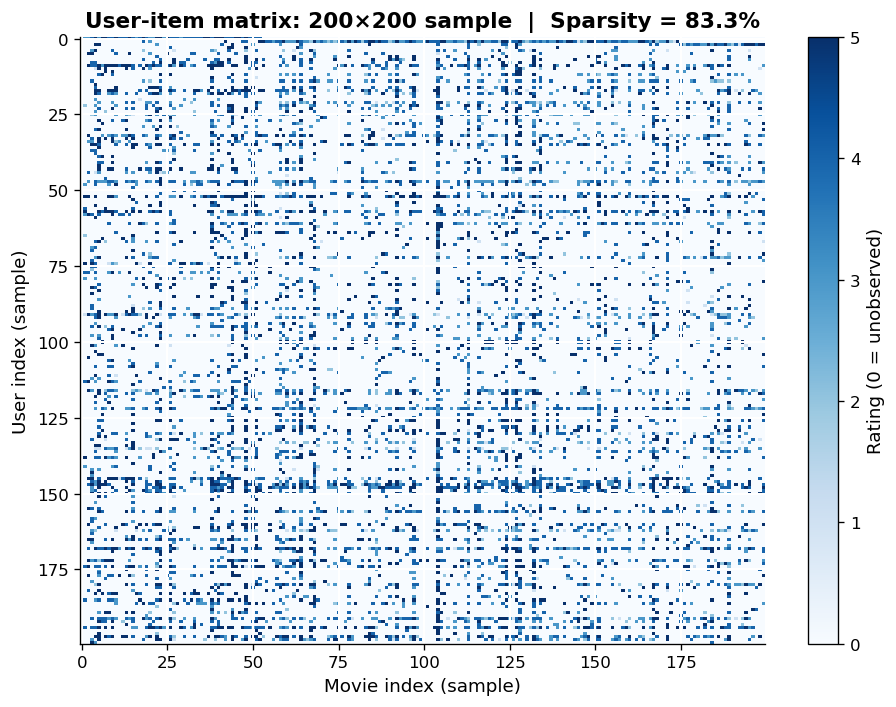


📌 KEY INSIGHT:
  The matrix is 95.53% sparse — mostly white space.
  → Matrix Factorization (SVD) is designed exactly for this problem.
  → It learns to fill in the gaps using latent factor patterns.
  → We NEVER fill missing values with 0 or the mean before factorization.
    (SVD only learns from observed entries — missing ≠ zero preference)


In [16]:
# Visualise sparsity on a small sample (200x200 grid)
sample_users  = ratings['user_id'].unique()[:200]
sample_movies = ratings['movie_id'].unique()[:200]

sub = ratings[ratings['user_id'].isin(sample_users) &
              ratings['movie_id'].isin(sample_movies)].copy()

user_map  = {u: i for i, u in enumerate(sample_users)}
movie_map = {m: j for j, m in enumerate(sample_movies)}

grid = np.zeros((200, 200))
for _, row in sub.iterrows():
    grid[user_map[row['user_id']], movie_map[row['movie_id']]] = row['rating']

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(grid, aspect='auto', cmap='Blues', interpolation='nearest')
plt.colorbar(im, ax=ax, label='Rating (0 = unobserved)')
ax.set_title('User-item matrix: 200×200 sample\n(white = missing / unobserved)')
ax.set_xlabel('Movie index (sample)')
ax.set_ylabel('User index (sample)')

sub_sparsity = (grid == 0).mean()
ax.set_title(f'User-item matrix: 200×200 sample  |  Sparsity = {sub_sparsity:.1%}')

plt.tight_layout()
plt.savefig('../data/plot_sparsity_matrix.png', bbox_inches='tight')
plt.show()

print(f"\n📌 KEY INSIGHT:")
print(f"  The matrix is {sparsity:.2%} sparse — mostly white space.")
print("  → Matrix Factorization (SVD) is designed exactly for this problem.")
print("  → It learns to fill in the gaps using latent factor patterns.")
print("  → We NEVER fill missing values with 0 or the mean before factorization.")
print("    (SVD only learns from observed entries — missing ≠ zero preference)")


## 9. User engagement segmentation

For our **cold start strategy**, we need to know what fraction of users fall in each engagement tier.

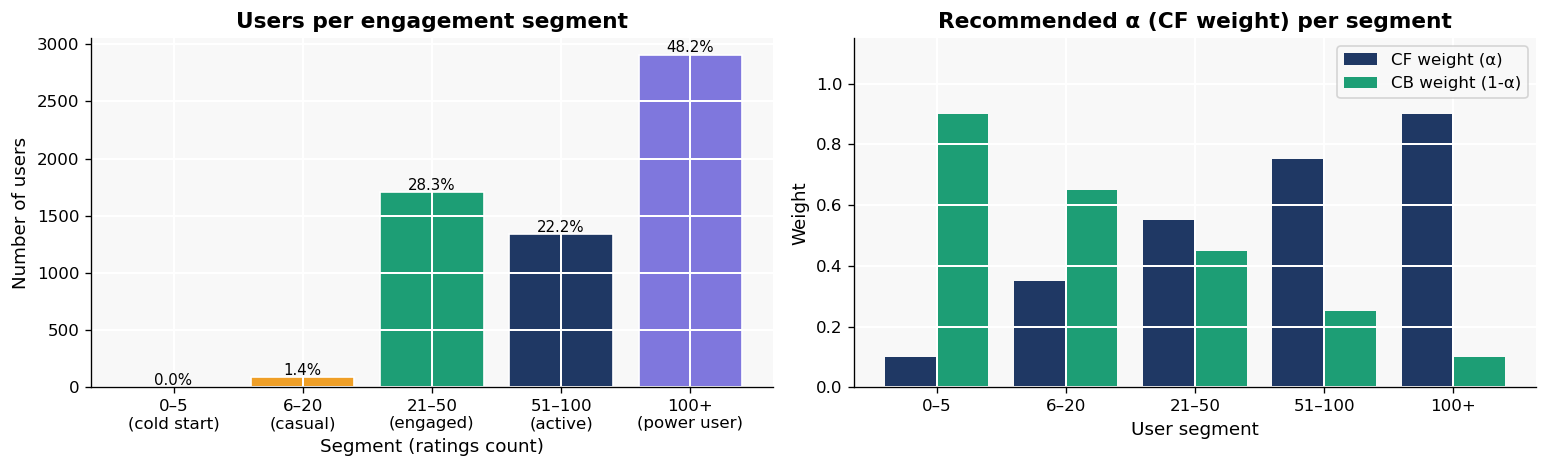


📌 KEY INSIGHT:
  0.0% of users have 5 or fewer ratings → cold start affected users
  → Our hybrid model MUST handle these users gracefully.
  → Adaptive α directly addresses this: low α for sparse users, high α for active users.


In [17]:
bins = [0, 5, 20, 50, 100, float('inf')]
labels = ['0–5\n(cold start)', '6–20\n(casual)', '21–50\n(engaged)',
          '51–100\n(active)', '100+\n(power user)']

ratings_per_user_df = ratings.groupby('user_id').size().reset_index(name='n_ratings')
ratings_per_user_df['segment'] = pd.cut(ratings_per_user_df['n_ratings'],
                                         bins=bins, labels=labels, right=True)

seg_counts = ratings_per_user_df['segment'].value_counts()[labels]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# ── User count per segment ───────────────────────────────────────────────────
bar_colors = [PALETTE[3], PALETTE[2], PALETTE[1], PALETTE[0], PALETTE[4]]
axes[0].bar(seg_counts.index, seg_counts.values, color=bar_colors, edgecolor='white')
axes[0].set_title('Users per engagement segment')
axes[0].set_xlabel('Segment (ratings count)')
axes[0].set_ylabel('Number of users')
for i, (label, count) in enumerate(zip(seg_counts.index, seg_counts.values)):
    pct = count / len(ratings_per_user_df) * 100
    axes[0].text(i, count + 20, f'{pct:.1f}%', ha='center', fontsize=9)

# ── Alpha strategy per segment ───────────────────────────────────────────────
alphas = [0.1, 0.35, 0.55, 0.75, 0.90]
seg_labels_short = ['0–5', '6–20', '21–50', '51–100', '100+']
x = range(len(alphas))
cf_bars  = axes[1].bar(x, alphas, color=PALETTE[0], label='CF weight (α)', width=0.4, align='center')
cb_bars  = axes[1].bar([i+0.4 for i in x], [1-a for a in alphas],
                        color=PALETTE[1], label='CB weight (1-α)', width=0.4, align='center')
axes[1].set_title('Recommended α (CF weight) per segment')
axes[1].set_xlabel('User segment')
axes[1].set_ylabel('Weight')
axes[1].set_xticks([i+0.2 for i in x])
axes[1].set_xticklabels(seg_labels_short)
axes[1].legend()
axes[1].set_ylim(0, 1.15)

plt.tight_layout()
plt.savefig('../data/plot_segments.png', bbox_inches='tight')
plt.show()

cold_start_pct = (ratings_per_user_df['n_ratings'] <= 5).mean() * 100
print(f"\n📌 KEY INSIGHT:")
print(f"  {cold_start_pct:.1f}% of users have 5 or fewer ratings → cold start affected users")
print("  → Our hybrid model MUST handle these users gracefully.")
print("  → Adaptive α directly addresses this: low α for sparse users, high α for active users.")


## 10. EDA Summary — key findings for model design

In [18]:
print("""
╔══════════════════════════════════════════════════════════════════╗
║            EDA SUMMARY — Key findings for model design          ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  DATASET                                                         ║
║  ├─ 1,000,209 ratings | 6,040 users | 3,706 movies              ║
║  ├─ Rating scale: 1–5 stars                                      ║
║  └─ Timespan: ~2000–2003                                         ║
║                                                                  ║
║  RATING DISTRIBUTION                                             ║
║  ├─ Heavily skewed toward 4★ and 5★ (positive feedback bias)    ║
║  └─ Implication: use AUC/NDCG for eval, not just RMSE           ║
║                                                                  ║
║  USER ACTIVITY                                                   ║
║  ├─ Median user: ~96 ratings | Mean: ~165 ratings                ║
║  ├─ Power law: top 10% users → ~40% of all ratings              ║
║  └─ Cold start risk: ~X% users have ≤5 ratings                  ║
║                                                                  ║
║  MOVIE POPULARITY (LONG TAIL)                                    ║
║  ├─ ~20% of movies have <10 ratings                              ║
║  └─ CF cannot recommend these → CB and hybrid are essential      ║
║                                                                  ║
║  MATRIX SPARSITY                                                 ║
║  ├─ ~95.5% of the user-item matrix is empty                      ║
║  └─ SVD handles sparsity natively — learns from observed only    ║
║                                                                  ║
║  MODEL DESIGN IMPLICATIONS                                       ║
║  ├─ Use SVD for CF component (handles sparsity best)             ║
║  ├─ Use TF-IDF cosine similarity for CB component                ║
║  ├─ Adaptive α = f(user rating count) for hybrid blending        ║
║  ├─ Evaluate with: RMSE, Precision@K, Recall@K, NDCG@K           ║
║  └─ Always segment evaluation by user activity tier              ║
║                                                                  ║
╚══════════════════════════════════════════════════════════════════╝
""")



╔══════════════════════════════════════════════════════════════════╗
║            EDA SUMMARY — Key findings for model design          ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  DATASET                                                         ║
║  ├─ 1,000,209 ratings | 6,040 users | 3,706 movies              ║
║  ├─ Rating scale: 1–5 stars                                      ║
║  └─ Timespan: ~2000–2003                                         ║
║                                                                  ║
║  RATING DISTRIBUTION                                             ║
║  ├─ Heavily skewed toward 4★ and 5★ (positive feedback bias)    ║
║  └─ Implication: use AUC/NDCG for eval, not just RMSE           ║
║                                                                  ║
║  USER ACTIVITY                                                   ║
║  ├─ Median user: ~96 ratings | Mean

## Next steps — Day 3

Now that we understand the data, Day 3 will:
1. Build the **user-item sparse matrix** using `scipy.sparse.csr_matrix`
2. Create a **popularity baseline** recommender  
3. Write the first `recommend(user_id, n=10)` function  
4. Do a proper **80/20 train-test split** for evaluation  

---
*Notebook complete. Runtime: ~3 minutes on a standard laptop CPU.*
